In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
def log_preprocessing(root_path):
    log_path = os.path.join(root_path, "download.txt")
    with open(log_path) as file:
        content = file.readlines()
    content = [log for log in content if "Loss" in log]
    logs = []

    for i in range(len(content)):
        epoch = content[i].split('│')
        loss = epoch[1].split('/')
        train_loss = float(loss[0][7:-1])
        val_loss = float(loss[1][1:-1])
        acc = float(epoch[2][-7:-1])
        f1 = float(epoch[3][-7:-1])
        k = float(epoch[4][-7:-1])
        mcc = float(epoch[5][-7:-1])
        lr = float(epoch[6][-9:-1])
        time = float(epoch[7][1:-4])
        logs.append([i+1, train_loss, val_loss, acc, f1, k, mcc, lr, time])

    columns = ["epoch", "train_loss", "val_loss", "acc", "f1", "k", "mcc", "lr", "time"]

    save_path = os.path.join(root_path, "log.csv")
    df = pd.DataFrame(logs, columns=columns)
    df.to_csv(save_path, index=False)

In [9]:
sca_edge = pd.read_csv(r"D:\Capstone\models\PT\CNN\SCALOGRAM\EdgeNeXTXXS\log.csv")
sca_ghost = pd.read_csv(r"D:\Capstone\models\PT\CNN\SCALOGRAM\GhostNetV3\log.csv")
sca_mobile = pd.read_csv(r"D:\Capstone\models\PT\CNN\SCALOGRAM\MobileNetV4\log.csv")
sca_tiny = pd.read_csv(r"D:\Capstone\models\PT\CNN\SCALOGRAM\TinyNetD\log.csv")

spe_edge = pd.read_csv(r"D:\Capstone\models\PT\CNN\SPECTROGRAM\EdgeNeXTXXS\log.csv")
spe_ghost = pd.read_csv(r"D:\Capstone\models\PT\CNN\SPECTROGRAM\GhostNetV3\log.csv")
spe_mobile = pd.read_csv(r"D:\Capstone\models\PT\CNN\SPECTROGRAM\MobileNetV4\log.csv")
spe_tiny = pd.read_csv(r"D:\Capstone\models\PT\CNN\SPECTROGRAM\TinyNetD\log.csv")

In [11]:
sca_models = {
    "EdgeNeXTXXS": sca_edge,
    "GhostNetV3": sca_ghost,
    "MobileNetV4": sca_mobile,
    "TinyNetD": sca_tiny
}

spe_models = {
    "EdgeNeXTXXS": spe_edge,
    "GhostNetV3": spe_ghost,
    "MobileNetV4": spe_mobile,
    "TinyNetD": spe_tiny
}

metrics = ['train_loss', 'val_loss', 'acc', 'f1', 'k', 'mcc', 'lr', 'time']

In [12]:
def plot_2x4_like_image(models_dict, title):
    plt.rcParams.update(plt.rcParamsDefault)

    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        ax = axes[i]

        for name, df in models_dict.items():
            ax.plot(
                df['epoch'],
                df[metric],
                linewidth=2,
                label=name
            )

        ax.set_title(metric)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric)

        ax.grid(True, linestyle='-', alpha=0.3)

        if metric in ['acc', 'f1', 'k', 'mcc']:
            ax.set_ylim(0, 1)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc='lower center',
        ncol=4
    )

    fig.suptitle(title, fontsize=14)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])

    plt.show()

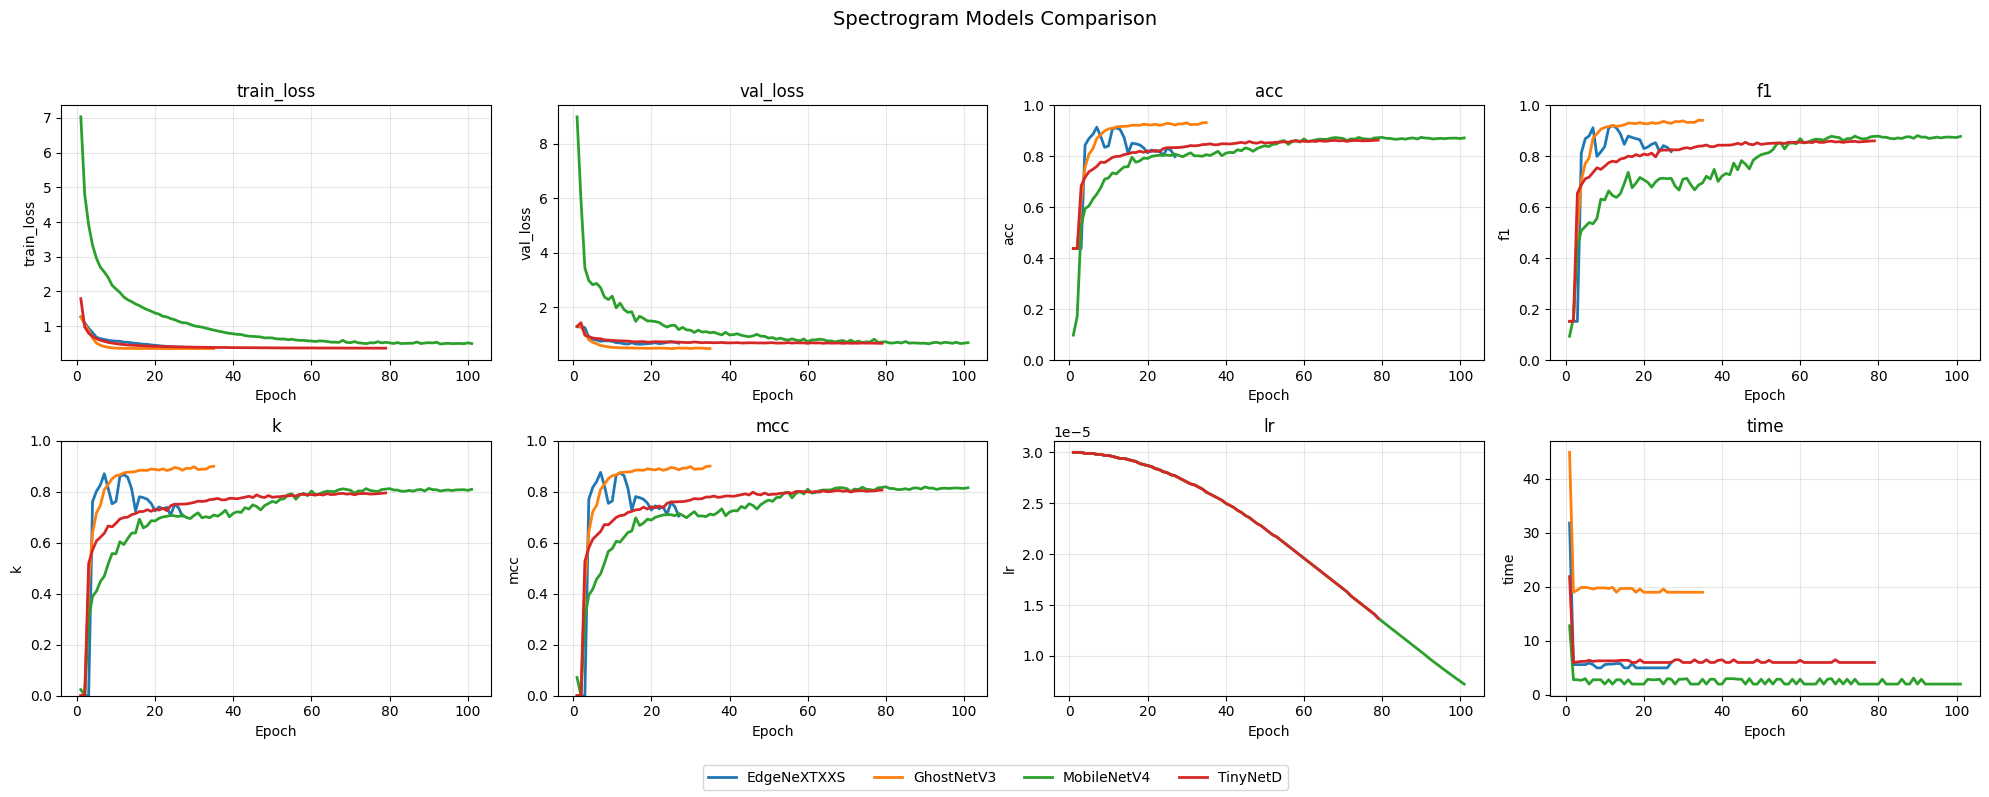

In [13]:
plot_2x4_like_image(spe_models, "Spectrogram Models Comparison")